In [1]:
from google.colab import files

uploaded = files.upload()

Saving covid_19_india.csv to covid_19_india.csv
Saving covid_vaccine_statewise.csv to covid_vaccine_statewise.csv
Saving StatewiseTestingDetails.csv to StatewiseTestingDetails.csv


   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----

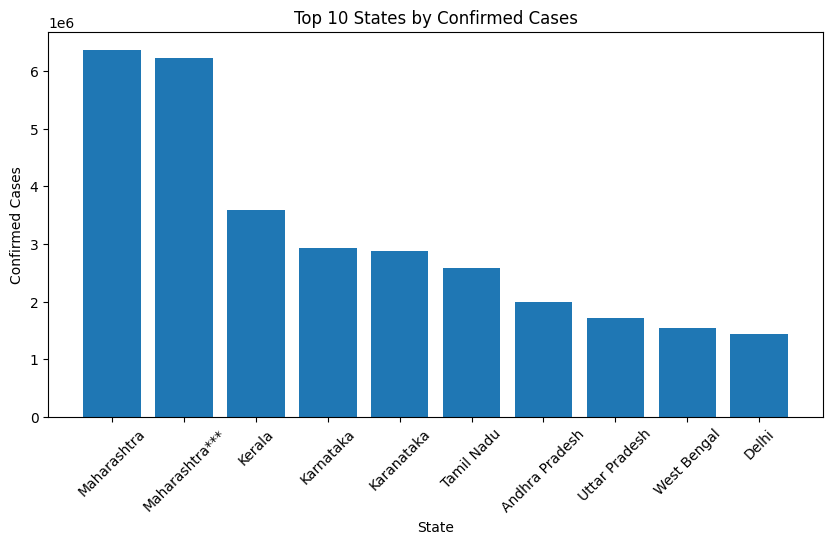

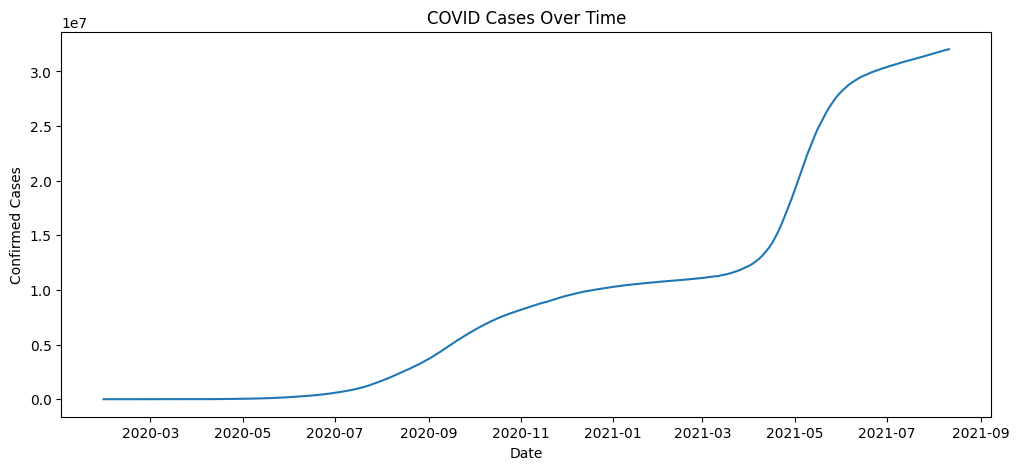

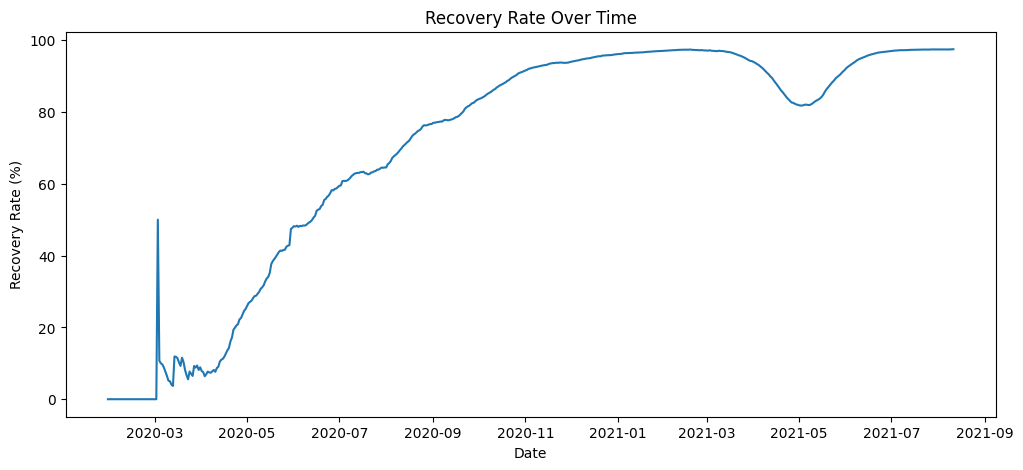

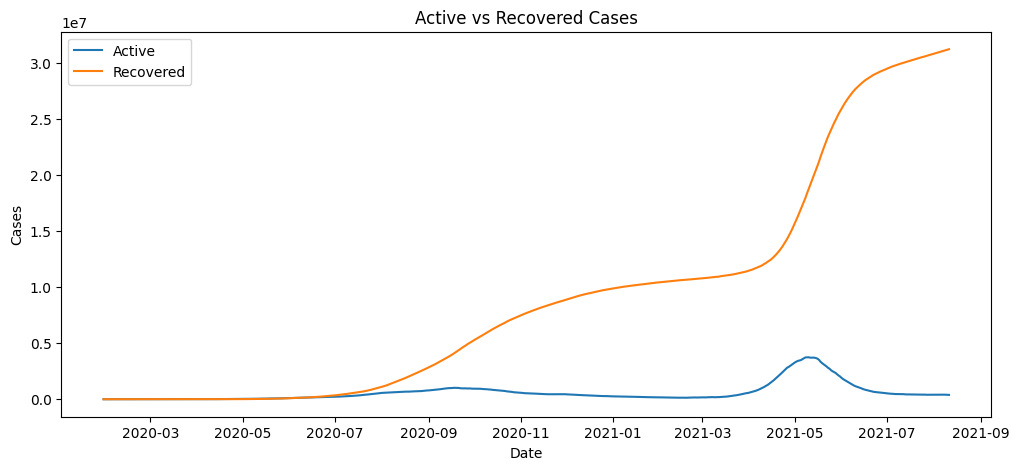

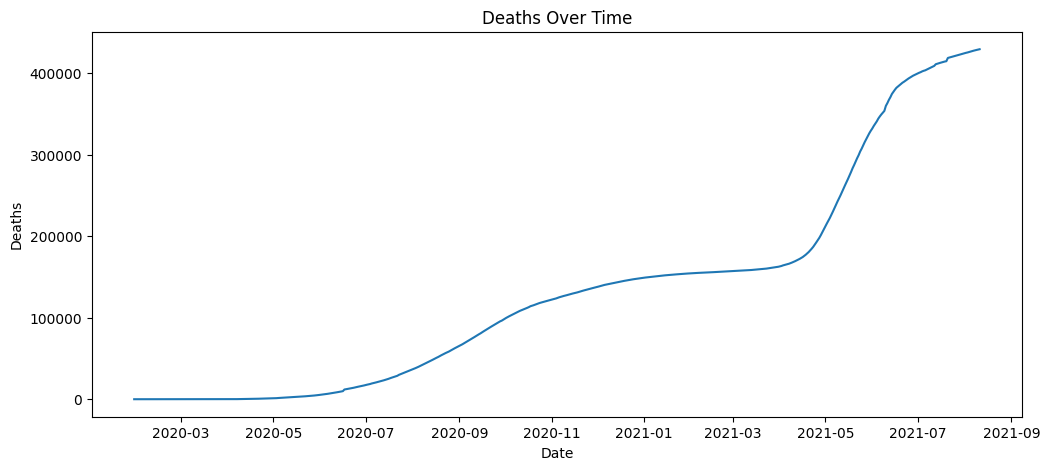

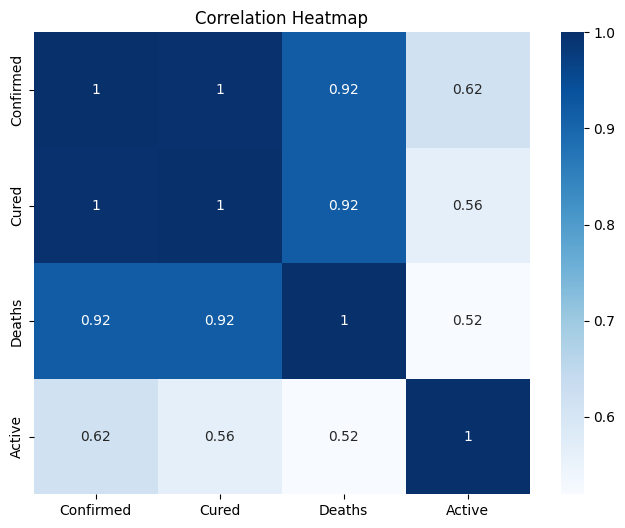

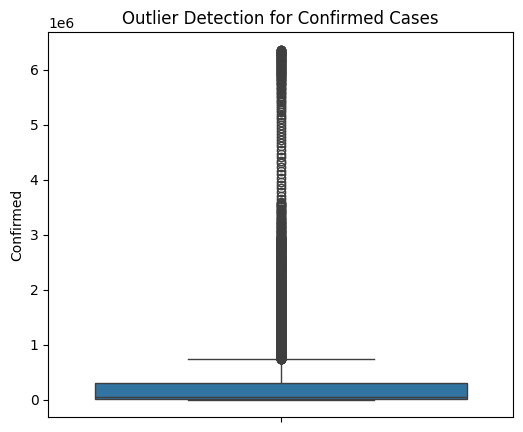

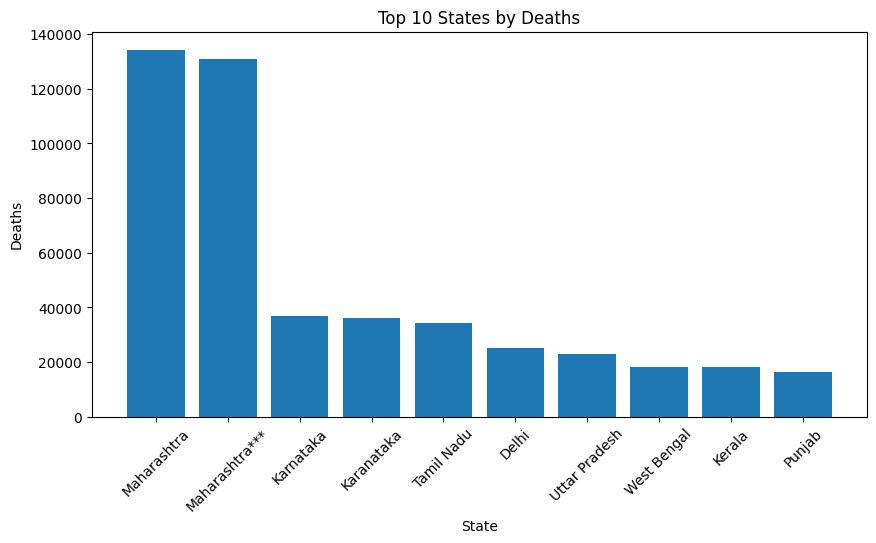

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("covid_19_india.csv")

# Explore Dataset
print(df.head())
print(df.info())
print(df.describe())

# Data Cleaning
df.dropna(inplace=True)
df["Date"] = pd.to_datetime(df["Date"])

# Create Active Cases
df["Active"] = df["Confirmed"] - df["Cured"] - df["Deaths"]


# Top 10 States by Confirmed Cases
state_cases = (
    df.groupby("State/UnionTerritory")["Confirmed"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(state_cases.index, state_cases.values)
plt.title("Top 10 States by Confirmed Cases")
plt.xlabel("State")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


# COVID Cases Over Time
daily_cases = (
    df.groupby("Date")["Confirmed"]
    .sum()
)

plt.figure(figsize=(12,5))
plt.plot(daily_cases.index, daily_cases.values)
plt.title("COVID Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()


# Recovery Rate Over Time
daily = (
    df.groupby("Date")[["Confirmed", "Cured"]]
    .sum()
)

daily["Recovery Rate"] = (
    daily["Cured"] / daily["Confirmed"]
) * 100

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily["Recovery Rate"])
plt.title("Recovery Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Recovery Rate (%)")
plt.show()


# Active vs Recovered Cases
trend = (
    df.groupby("Date")[["Active", "Cured"]]
    .sum()
)

plt.figure(figsize=(12,5))
plt.plot(trend.index, trend["Active"], label="Active")
plt.plot(trend.index, trend["Cured"], label="Recovered")
plt.title("Active vs Recovered Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()


# Deaths Over Time
deaths = (
    df.groupby("Date")["Deaths"]
    .sum()
)

plt.figure(figsize=(12,5))
plt.plot(deaths.index, deaths.values)
plt.title("Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()


# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["Confirmed", "Cured", "Deaths", "Active"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()


# Outlier Detection
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Confirmed"])
plt.title("Outlier Detection for Confirmed Cases")
plt.show()


# Top 10 States by Deaths
top_deaths = (
    df.groupby("State/UnionTerritory")["Deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(top_deaths.index, top_deaths.values)
plt.title("Top 10 States by Deaths")
plt.xlabel("State")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.show()